# Employee promotion and Airbnb pricing

This walkthrough presents the **2026 evaluation revision** of 2023–2024 coursework.
The original notebooks are in `archive/`. Their headline results were withdrawn
because of leakage. The current implementation and full findings are linked from
the repository README.

The cells below read the committed aggregate results. They do not pretend to
retrain the models when the input datasets are unavailable.

In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd() if (Path.cwd() / "src").is_dir() else Path.cwd().parent
assert (ROOT / "src").is_dir(), "Open this notebook from the repository or notebooks directory."
sys.path.insert(0, str(ROOT))
results = json.loads((ROOT / "results/metrics.json").read_text(encoding="utf-8"))
print("Evaluation revision:", results["review_date"])
print("Python:", results["python"])
print("Random seed:", results["seed"])

Evaluation revision: 2026-10-06
Python: 3.12.14
Random seed: 42


## 1. Employee promotion

The original dataset contains 54,808 employees, with only 8.52% promoted. The revised
pipeline keeps nominal categories as one-hot features and builds the original
performance-sum and training-effectiveness concepts. Imputation and scaling are
fitted within the training folds. Class weighting is compared without SMOTE.

Three-fold stratified CV selects the family and hyperparameters using average
precision. The holdout never participates in this selection.

In [2]:
hr = results["hr"]
print("Selected model:", hr["selected_model"])
print("Training / test rows:", hr["train_rows"], "/", hr["test_rows"])
display(pd.DataFrame(hr["cv"])[["model", "cv_score", "cv_std", "best_params"]])
display(pd.DataFrame({"Selected model": hr["test"], "Baseline": hr["baseline_test"]}).round(4))

Selected model: Histogram gradient boosting
Training / test rows: 41106 / 13702


,model,cv_score,cv_std,best_params
0,Logistic regression,0.513460,0.014627,"{'model__C': 1.0, 'model__class_weight': None}"
1,Random forest,0.566398,0.007564,"{'model__class_weight': None, 'model__min_samp..."
2,Histogram gradient boosting,0.590991,0.010486,{'model__max_leaf_nodes': 15}


,Selected model,Baseline
accuracy,0.9426,0.9148
balanced_accuracy,0.6698,0.5000
precision,0.9590,0.0000
recall,0.3410,0.0000
f1,0.5032,0.0000
average_precision,0.6118,0.0852
roc_auc,0.9092,0.5000


,Predicted not promoted,Predicted promoted
Actual not promoted,12518,17
Actual promoted,769,398


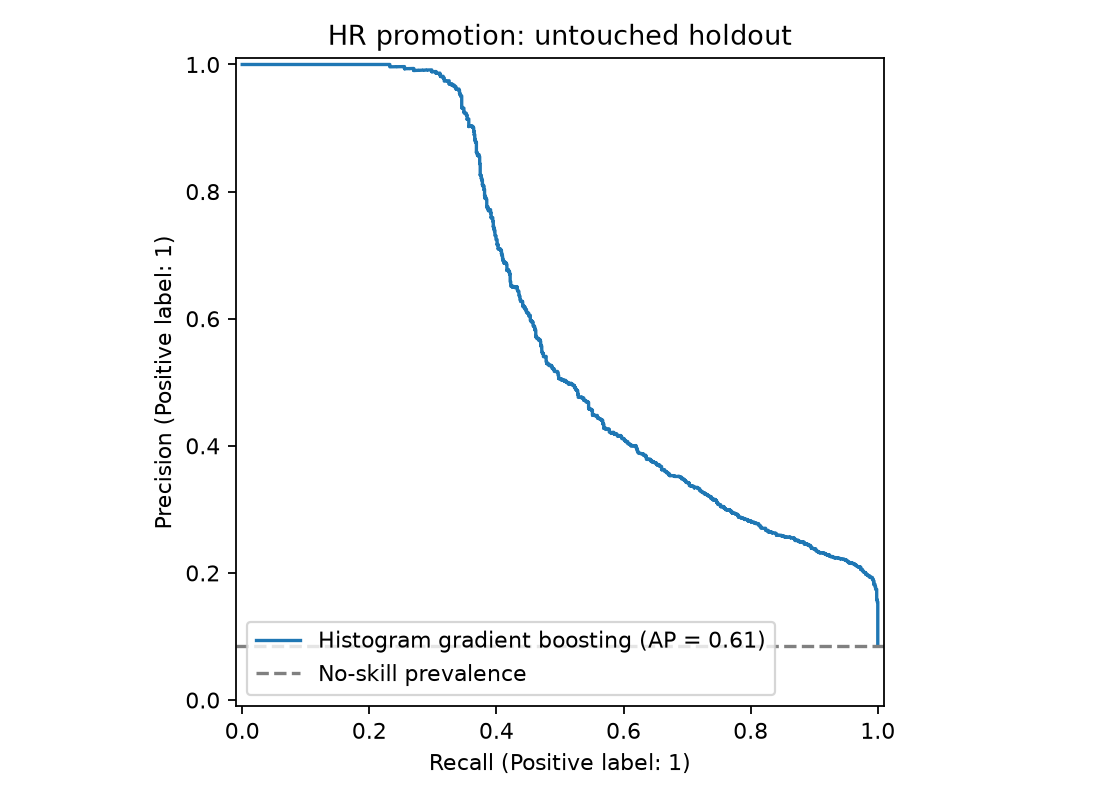

In [3]:
display(pd.DataFrame(hr["confusion_matrix"],
    index=["Actual not promoted", "Actual promoted"],
    columns=["Predicted not promoted", "Predicted promoted"]))
display(Image(filename=str(ROOT / "results/hr_precision_recall.png")))

At the fixed 0.5 threshold, promotion precision is 95.90% but recall is 34.10%.
The model finds 398 promotions and misses 769. Accuracy of 94.26% should always
be read alongside the 91.48% majority baseline. Threshold selection would require
training-only validation and a defined decision cost; it was not done here.

## 2. Airbnb pricing

The study retains the Central Region scope. One zero-price listing is removed,
leaving 6,308 rows. Training and test sets contain different hosts. All model
selection and stacking inner folds also keep hosts separate.

Features include room type, neighbourhood, coordinates, stay rules, availability,
review count, host listing count, location clusters, neighbourhood counts and
nearest-MRT distance. No feature includes the target price. Learned geographic
features are fitted within each training fold. MRT distances use fixed reference
coordinates and a spherical approximation, not walking travel times.

In [4]:
air = results["airbnb"]
print("Selected model:", air["selected_model"])
print("Training / test hosts:", air["train_hosts"], "/", air["test_hosts"])
print("Host overlap:", air["host_overlap"])
cv = pd.DataFrame(air["cv"])
cv["CV log-price RMSE"] = -cv["cv_score"]
display(cv[["model", "CV log-price RMSE", "cv_std", "best_params"]])
display(pd.DataFrame({"Selected model": air["test"], "Baseline": air["baseline_test"]}).round(4))

Selected model: Group-aware stacking
Training / test hosts: 1400 / 350
Host overlap: 0


,model,CV log-price RMSE,cv_std,best_params
0,Ridge regression,0.542901,0.015048,{'model__alpha': 10.0}
1,Random forest,0.517534,0.030903,{'model__min_samples_leaf': 8}
2,Histogram gradient boosting,0.510753,0.028174,{'model__max_leaf_nodes': 15}
3,Group-aware stacking,0.508359,0.032773,{}


,Selected model,Baseline
rmse_log1p,0.4505,0.7936
r2_log1p,0.6744,-0.0105
mae_price_units,67.6359,103.3867
rmse_price_units,332.6154,368.1849
r2_price_units,0.1731,-0.0132


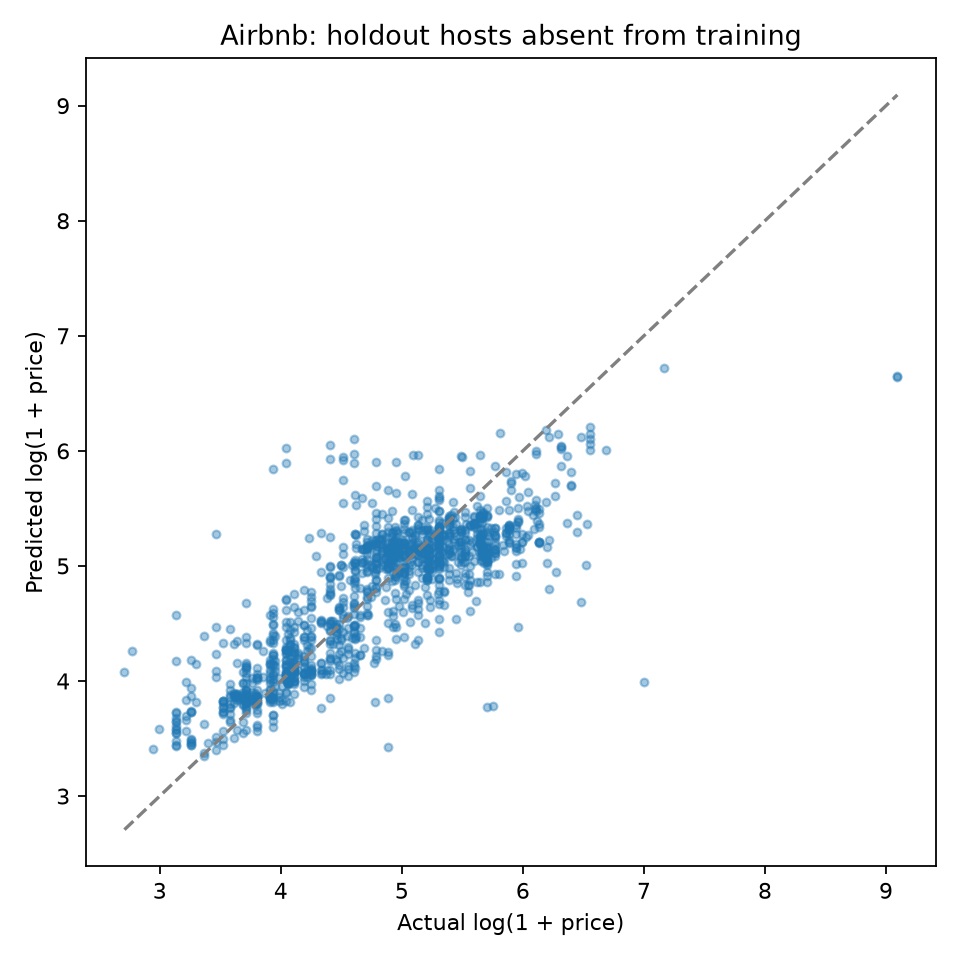

In [5]:
display(Image(filename=str(ROOT / "results/airbnb_predictions.png")))

The selected stack uses Random Forest and histogram gradient boosting, with a
ridge meta-model. Out-of-fold predictions train the meta-model; test answers are
never used. The revised stack differs from the historical RF/XGBoost experiment.

Log-price R² is 0.674, while original-price R² is 0.173. Extreme prices remain
hard to predict. Original-scale MAE is 67.64 **dataset price units**; the source
currency was not verified. The tiny CV advantage of stacking over histogram
boosting does not establish statistically significant superiority.

## 3. Reproduce or inspect

The default below reads the existing results only. To retrain, obtain the three
inputs described in `data/raw/README.md`, set `DATA_DIR` and enable `RUN_TRAINING`.
This reruns the complete current benchmark and overwrites the aggregate results
and figures. Rerun this notebook from the top afterward to refresh its displays.

The five tests run without the private datasets using `python -m unittest discover -s tests -v`.
Input hashes and tested package versions are recorded in `results/metrics.json`.

In [6]:
RUN_TRAINING = False
DATA_DIR = ROOT / "data/raw"
if RUN_TRAINING:
    from src.evaluate import run
    from threadpoolctl import threadpool_limits
    with threadpool_limits(limits=2):
        results = run(DATA_DIR, ROOT / "results")
else:
    print("Displaying committed results; training was not rerun by this notebook.")

Displaying committed results; training was not rerun by this notebook.


## 4. Limits

These are retrospective results on old coursework data. Source links, dataset
terms and snapshot dates still need verification. No production deployment,
fairness guarantee, causal effect of MRT access or Singapore-wide forecasting
accuracy is established. See `docs/REVIEW.md` for original-source findings and
all changes made during this later review.